<a href="https://colab.research.google.com/github/Mambey1/AI-CourseWork/blob/main/2432871_BijayPandey_Text_Classification_Part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 — Final Portfolio Assessment 2026
## Part III: Language Tasks — Sarcasm Detection
### RNN · LSTM · LSTM + GloVe Embeddings

---
| | |
|---|---|
| **Institution** | Herald College Kathmandu / University of Wolverhampton |
| **Module** | Artificial Intelligence and Machine Learning (6CS012) |
| **Dataset** | Sarcastic or Not — News Headlines (28,619 records) |
| **Task** | Binary Text Classification: Sarcastic vs Not Sarcastic |
| **Models** | Simple RNN · Stacked LSTM · LSTM + Pretrained GloVe |
| **Framework** | TensorFlow / Keras |


---
## 📦 Step 0 — Install & Import

In [ ]:
# Install required packages — do NOT pin/downgrade numpy
!pip install -q --upgrade gensim
!pip install -q wordcloud gradio contractions

import gensim, numpy as np, gradio
print(f'gensim  : {gensim.__version__}')
print(f'numpy   : {np.__version__}')
print(f'gradio  : {gradio.__version__}')
print('All packages ready.')

gensim  : 4.4.0
numpy   : 2.0.2
gradio  : 5.50.0
All packages ready.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, re, time
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
import contractions as contractions_lib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

for pkg in ['stopwords','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)

# Global dark plot style
plt.rcParams.update({
    'figure.facecolor':'#0f0f0f','axes.facecolor':'#1a1a2e',
    'axes.edgecolor':'#444','axes.labelcolor':'#e0e0e0',
    'xtick.color':'#aaa','ytick.color':'#aaa','text.color':'#e0e0e0',
    'grid.color':'#333','grid.linestyle':'--','grid.alpha':0.5,
    'font.family':'monospace'
})
C = {'s':'#ff6b6b','n':'#4ecdc4','m1':'#ff6b6b','m2':'#4ecdc4','m3':'#ffe66d'}

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 📂 Step 1 — Load & Explore Dataset

In [1]:
from google.colab import files
print('Upload sarcastic_headlines.csv')
files.upload()

Upload sarcastic_headlines.csv


TypeError: 'NoneType' object is not subscriptable

In [ ]:
df = pd.read_csv('sarcastic_headlines.csv')
counts = df['is_sarcastic'].value_counts()

print('='*55)
print('  DATASET OVERVIEW')
print('='*55)
print(f'  Total records      : {len(df):,}')
print(f'  Columns            : {list(df.columns)}')
print(f'  Missing values     : {df.isnull().sum().sum()}')
print(f'  Duplicate rows     : {df.duplicated().sum()}')
print(f'  Sarcastic (1)      : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)')
print(f'  Not Sarcastic (0)  : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)')
print('='*55)
df.head(8)

  DATASET OVERVIEW
  Total records      : 28,619
  Columns            : ['headline', 'is_sarcastic']
  Missing values     : 0
  Duplicate rows     : 116
  Sarcastic (1)      : 13,634  (47.6%)
  Not Sarcastic (0)  : 14,985  (52.4%)


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1
5,my white inheritance,0
6,5 ways to file your taxes with less stress,0
7,richard branson's global-warming donation near...,1


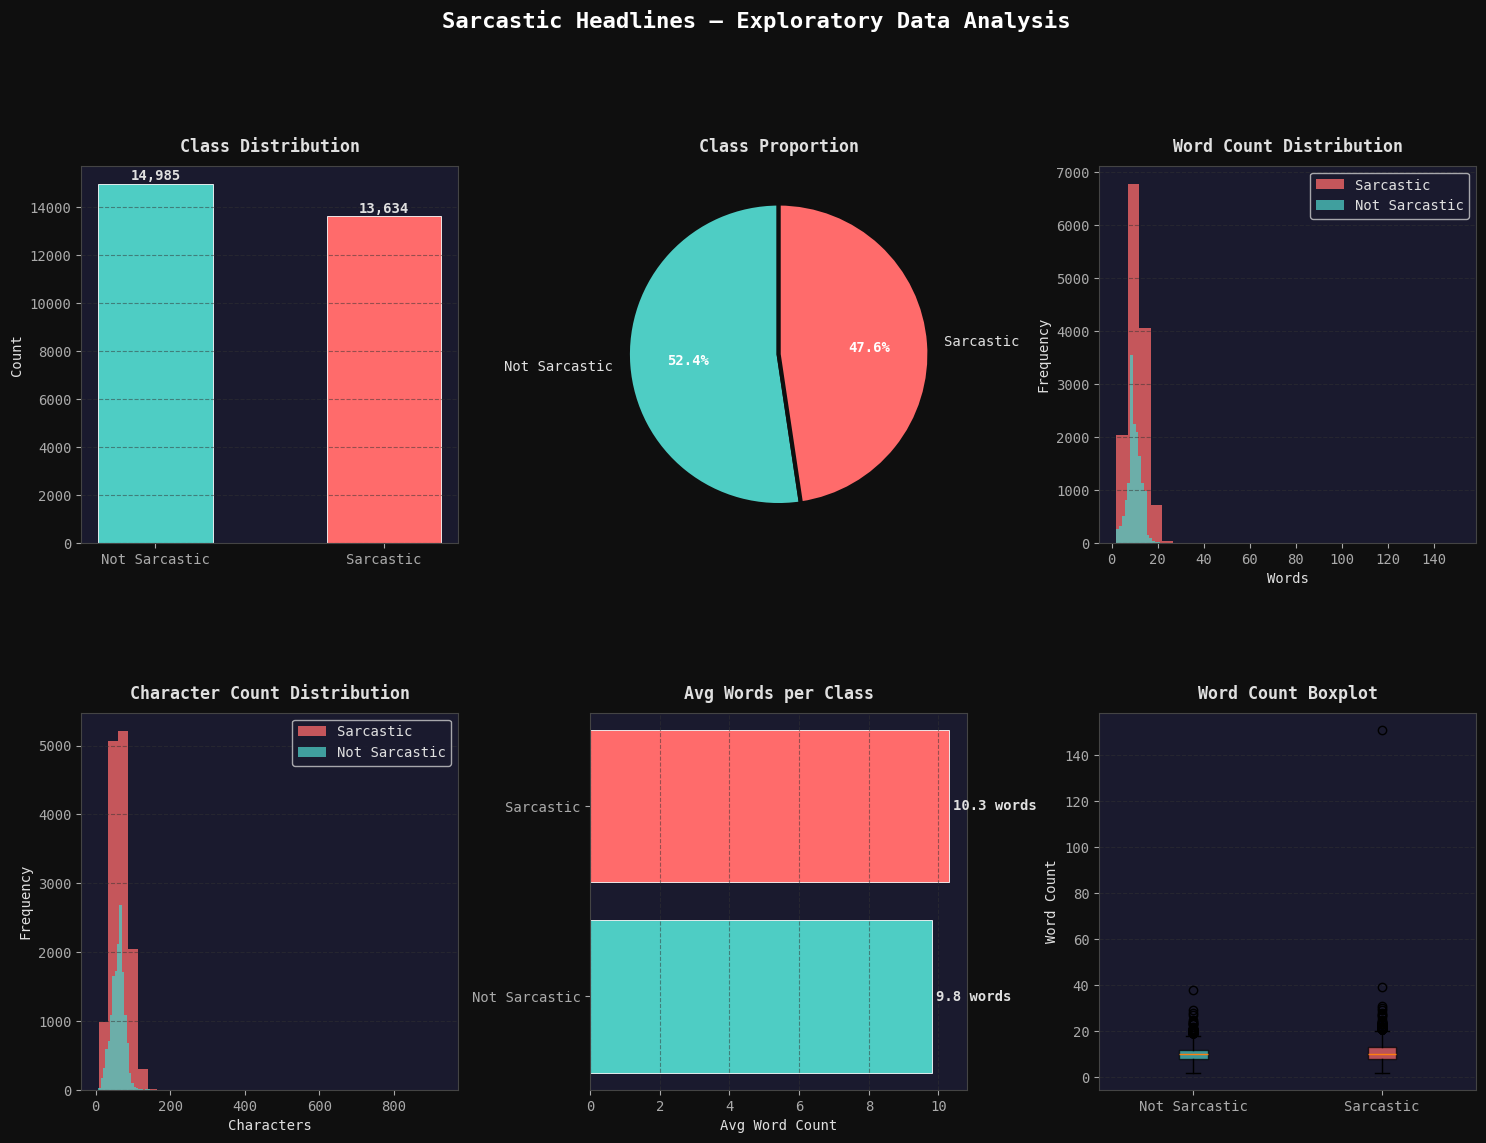

In [ ]:
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(len)

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0f0f0f')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1 — Bar chart
ax1 = fig.add_subplot(gs[0,0])
bars = ax1.bar(['Not Sarcastic','Sarcastic'],[counts[0],counts[1]],
               color=[C['n'],C['s']],edgecolor='white',linewidth=0.6,width=0.5)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2,b.get_height()+150,
             f'{b.get_height():,}',ha='center',fontweight='bold')
ax1.set_title('Class Distribution',fontweight='bold',pad=10)
ax1.set_ylabel('Count'); ax1.grid(axis='y')

# 2 — Pie
ax2 = fig.add_subplot(gs[0,1])
wedges,texts,autotexts = ax2.pie(
    [counts[0],counts[1]],labels=['Not Sarcastic','Sarcastic'],
    autopct='%1.1f%%',colors=[C['n'],C['s']],startangle=90,
    wedgeprops={'edgecolor':'#0f0f0f','linewidth':3})
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax2.set_title('Class Proportion',fontweight='bold',pad=10)

# 3 — Word count histogram
ax3 = fig.add_subplot(gs[0,2])
ax3.hist(df[df['is_sarcastic']==1]['word_count'],bins=30,alpha=0.75,label='Sarcastic',color=C['s'])
ax3.hist(df[df['is_sarcastic']==0]['word_count'],bins=30,alpha=0.75,label='Not Sarcastic',color=C['n'])
ax3.set_title('Word Count Distribution',fontweight='bold',pad=10)
ax3.set_xlabel('Words'); ax3.set_ylabel('Frequency')
ax3.legend(); ax3.grid(axis='y')

# 4 — Char count
ax4 = fig.add_subplot(gs[1,0])
ax4.hist(df[df['is_sarcastic']==1]['char_count'],bins=35,alpha=0.75,label='Sarcastic',color=C['s'])
ax4.hist(df[df['is_sarcastic']==0]['char_count'],bins=35,alpha=0.75,label='Not Sarcastic',color=C['n'])
ax4.set_title('Character Count Distribution',fontweight='bold',pad=10)
ax4.set_xlabel('Characters'); ax4.set_ylabel('Frequency')
ax4.legend(); ax4.grid(axis='y')

# 5 — Avg words per class
ax5 = fig.add_subplot(gs[1,1])
avg = df.groupby('is_sarcastic')['word_count'].mean()
ax5.barh(['Not Sarcastic','Sarcastic'],[avg[0],avg[1]],
         color=[C['n'],C['s']],edgecolor='white',linewidth=0.6)
for i,v in enumerate([avg[0],avg[1]]):
    ax5.text(v+0.1,i,f'{v:.1f} words',va='center',fontweight='bold')
ax5.set_title('Avg Words per Class',fontweight='bold',pad=10)
ax5.set_xlabel('Avg Word Count'); ax5.grid(axis='x')

# 6 — Box plot
ax6 = fig.add_subplot(gs[1,2])
bp  = ax6.boxplot(
    [df[df['is_sarcastic']==0]['word_count'].values,
     df[df['is_sarcastic']==1]['word_count'].values],
    labels=['Not Sarcastic','Sarcastic'],patch_artist=True)
for patch,color in zip(bp['boxes'],[C['n'],C['s']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax6.set_title('Word Count Boxplot',fontweight='bold',pad=10)
ax6.set_ylabel('Word Count'); ax6.grid(axis='y')

fig.suptitle('Sarcastic Headlines — Exploratory Data Analysis',
             fontsize=16,fontweight='bold',color='white',y=1.01)
plt.savefig('eda_plots.png',dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.show()

---
## 🧹 Step 2 — Text Preprocessing & Cleaning

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Preprocessing pipeline:
      1. Lowercase
      2. Expand contractions     (don't -> do not)
      3. Remove URLs
      4. Remove @mentions/#tags
      5. Remove digits
      6. Remove punctuation
      7. Tokenize
      8. Remove stopwords
      9. Lemmatize
    """
    text = str(text).lower()
    text = contractions_lib.fix(text)
    text = re.sub(r'http\S+|www\S+','',text)
    text = re.sub(r'@\w+|#\w+','',text)
    text = re.sub(r'\d+','',text)
    text = re.sub(r'[^\w\s]','',text)
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)

print('Cleaning text...')
t0 = time.time()
df['cleaned_headline'] = df['headline'].apply(clean_text)
print(f'Done in {time.time()-t0:.1f}s')

print('\nBEFORE vs AFTER (5 samples):')
print('-'*65)
for i in range(5):
    print(f'  Original : {df["headline"].iloc[i]}')
    print(f'  Cleaned  : {df["cleaned_headline"].iloc[i]}')
    print()

Cleaning text...
Done in 1.5s

BEFORE vs AFTER (5 samples):
-----------------------------------------------------------------
  Original : thirtysomething scientists unveil doomsday clock of hair loss
  Cleaned  : thirtysomething scientist unveil doomsday clock hair loss

  Original : dem rep. totally nails why congress is falling short on gender, racial equality
  Cleaned  : dem rep totally nail congress falling short gender racial equality

  Original : eat your veggies: 9 deliciously different recipes
  Cleaned  : eat veggie deliciously different recipe

  Original : inclement weather prevents liar from getting to work
  Cleaned  : inclement weather prevents liar getting work

  Original : mother comes pretty close to using word 'streaming' correctly
  Cleaned  : mother come pretty close using word streaming correctly



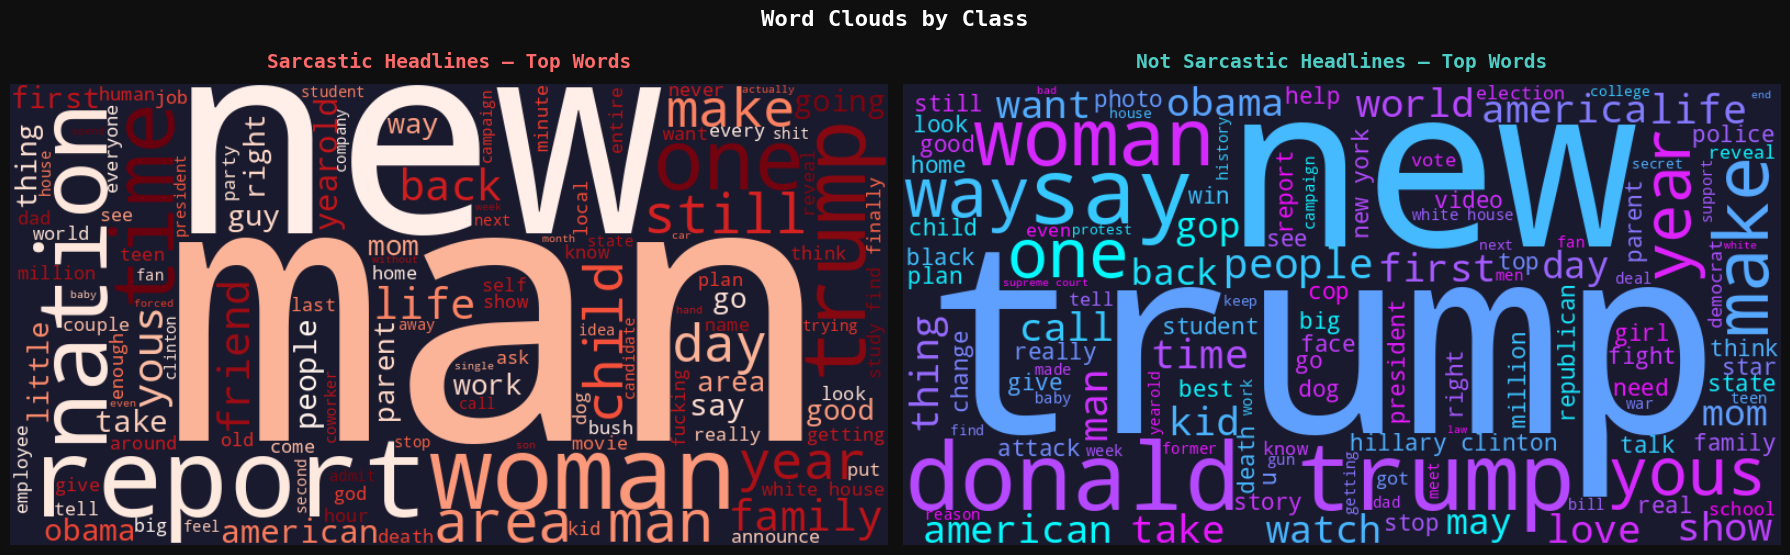

In [ ]:
# Word Clouds
sarc_text = ' '.join(df[df['is_sarcastic']==1]['cleaned_headline'])
not_text  = ' '.join(df[df['is_sarcastic']==0]['cleaned_headline'])

fig, axes = plt.subplots(1,2,figsize=(18,6))
fig.patch.set_facecolor('#0f0f0f')

wc1 = WordCloud(width=800,height=420,background_color='#1a1a2e',
                colormap='Reds',max_words=120,
                contour_color='#ff6b6b',contour_width=2).generate(sarc_text)
axes[0].imshow(wc1,interpolation='bilinear'); axes[0].axis('off')
axes[0].set_title('Sarcastic Headlines — Top Words',
                   fontsize=14,fontweight='bold',color='#ff6b6b',pad=12)

wc2 = WordCloud(width=800,height=420,background_color='#1a1a2e',
                colormap='cool',max_words=120,
                contour_color='#4ecdc4',contour_width=2).generate(not_text)
axes[1].imshow(wc2,interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('Not Sarcastic Headlines — Top Words',
                   fontsize=14,fontweight='bold',color='#4ecdc4',pad=12)

fig.suptitle('Word Clouds by Class',fontsize=16,fontweight='bold',color='white')
plt.tight_layout()
plt.savefig('wordclouds.png',dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.show()

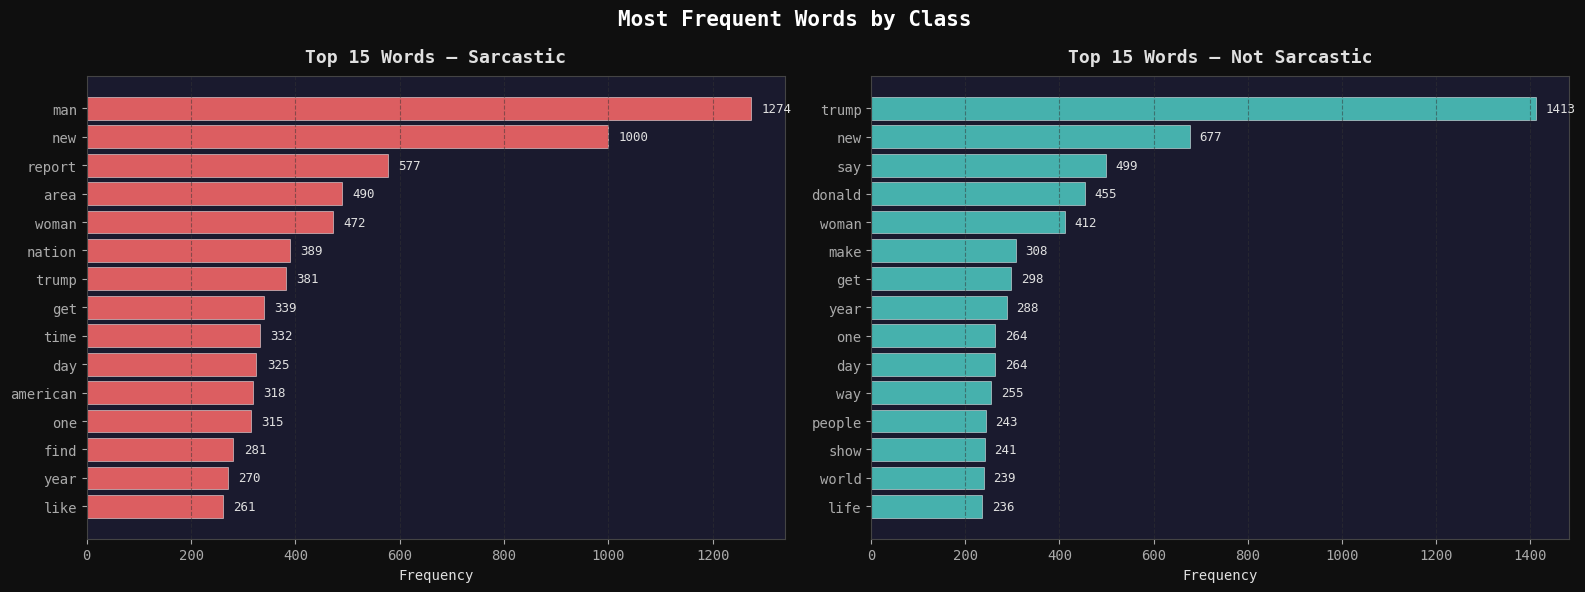

In [ ]:
# Top 15 words per class
def top_words(series, n=15):
    return Counter(' '.join(series).split()).most_common(n)

top_s = top_words(df[df['is_sarcastic']==1]['cleaned_headline'])
top_n = top_words(df[df['is_sarcastic']==0]['cleaned_headline'])

fig, axes = plt.subplots(1,2,figsize=(16,6))
fig.patch.set_facecolor('#0f0f0f')

for ax, data, title, color in [
    (axes[0], top_s, 'Sarcastic',     C['s']),
    (axes[1], top_n, 'Not Sarcastic', C['n'])
]:
    words, cnts = zip(*data)
    bars = ax.barh(words[::-1],cnts[::-1],color=color,alpha=0.85,
                   edgecolor='white',linewidth=0.4)
    for bar,cnt in zip(bars,cnts[::-1]):
        ax.text(bar.get_width()+20,bar.get_y()+bar.get_height()/2,
                str(cnt),va='center',fontsize=9)
    ax.set_title(f'Top 15 Words — {title}',fontweight='bold',fontsize=13,pad=10)
    ax.set_xlabel('Frequency'); ax.grid(axis='x')

fig.suptitle('Most Frequent Words by Class',fontsize=15,fontweight='bold',color='white')
plt.tight_layout()
plt.savefig('top_words.png',dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.show()

---
## ✂️ Step 3 — Tokenization, Padding & Train/Test Split

In [ ]:
MAX_VOCAB = 20000
OOV_TOKEN = '<OOV>'

X = df['cleaned_headline'].values
y = df['is_sarcastic'].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,}  ({y_train.mean()*100:.1f}% sarcastic)')
print(f'Test  : {len(X_test):,}   ({y_test.mean()*100:.1f}% sarcastic)')

# Class weights to handle any imbalance
cw = compute_class_weight('balanced',classes=np.unique(y_train),y=y_train)
class_weight_dict = {0:float(cw[0]), 1:float(cw[1])}
print(f'Class weights : {class_weight_dict}')

# Tokenize on training data only
tokenizer = Tokenizer(num_words=MAX_VOCAB,oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
vocab_size  = min(MAX_VOCAB, len(word_index)+1)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad to 95th percentile length
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths,95))

X_train_pad = pad_sequences(X_train_seq,maxlen=MAX_LEN,padding='post',truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN,padding='post',truncating='post')

print(f'\nVocabulary size          : {vocab_size:,}')
print(f'Max sequence length (95p): {MAX_LEN}')
print(f'X_train_pad shape        : {X_train_pad.shape}')
print(f'X_test_pad  shape        : {X_test_pad.shape}')

Train : 22,895  (47.6% sarcastic)
Test  : 5,724   (47.6% sarcastic)
Class weights : {0: 0.9549132465799133, 1: 1.0495553314385258}

Vocabulary size          : 20,000
Max sequence length (95p): 11
X_train_pad shape        : (22895, 11)
X_test_pad  shape        : (5724, 11)


---
## 🤖 Step 4 — Build Models
### Model 1 — Simple RNN + Trainable Embedding

In [ ]:
EMBED_DIM = 128

def build_rnn():
    m = Sequential(name='Simple_RNN')
    m.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                    input_length=MAX_LEN))
    m.add(SimpleRNN(64, return_sequences=False))
    m.add(Dropout(0.5))          # increased from 0.4
    m.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-3)))  # stronger L2
    m.add(Dropout(0.4))          # increased from 0.3
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.build(input_shape=(None, MAX_LEN))
    return m

model_rnn = build_rnn()
model_rnn.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 11, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — Stacked LSTM + BatchNorm + Trainable Embedding

In [ ]:
def build_lstm():
    m = Sequential(name='Stacked_LSTM')
    m.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                    input_length=MAX_LEN))
    m.add(LSTM(128, return_sequences=True))
    m.add(Dropout(0.2))
    m.add(LSTM(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(BatchNormalization())
    m.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    m.add(Dropout(0.4))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.build(input_shape=(None, MAX_LEN))
    return m

model_lstm = build_lstm()
model_lstm.summary()

Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 11, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 11, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,745,473 (10.47 MB)

 Trainable params: 2,745,345 (10.47 MB)

 Non-trainable params: 128 (512.00 B)

### Model 3 — Stacked LSTM + Pretrained GloVe Embeddings (Word2Vec)

In [ ]:
import gensim.downloader as api
print('Downloading GloVe (glove-wiki-gigaword-50)...')
glove = api.load('glove-wiki-gigaword-50')
print('Done!')

Done!


In [ ]:
GLOVE_DIM  = 50
emb_matrix = np.zeros((vocab_size, GLOVE_DIM))
found = 0
for word, idx in word_index.items():
    if idx < vocab_size and word in glove:
        emb_matrix[idx] = glove[word]
        found += 1
print(f'Words matched  : {found:,}')
print(f'Coverage       : {found/min(len(word_index),vocab_size)*100:.1f}%')
print(f'Matrix shape   : {emb_matrix.shape}')

Words matched  : 17,764
Coverage       : 88.8%
Matrix shape   : (20000, 50)


In [ ]:
def build_lstm_glove():
    m = Sequential(name='LSTM_GloVe')
    m.add(Embedding(input_dim=vocab_size, output_dim=GLOVE_DIM,
                    weights=[emb_matrix],
                    input_length=MAX_LEN,
                    trainable=False))          # ← back to frozen
    m.add(LSTM(128, return_sequences=True))    # ← back to stacked
    m.add(Dropout(0.2))
    m.add(LSTM(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(BatchNormalization())
    m.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    m.add(Dropout(0.4))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam',               # ← back to default adam
              loss='binary_crossentropy',
              metrics=['accuracy'])
    m.build(input_shape=(None, MAX_LEN))
    return m

model_glove = build_lstm_glove()
model_glove.summary()

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 11, 50)         │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 11, 128)        │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,537 (4.37 MB)

 Trainable params: 145,409 (568.00 KB)

 Non-trainable params: 1,000,128 (3.82 MB)

---
## 🏋️ Step 5 — Train All Models

In [ ]:
EPOCHS     = 20
BATCH_SIZE = 128

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=2, min_lr=1e-6, verbose=1)
]

def train_model(model, name):
    print(f'\n{"="*55}\n  Training: {name}\n{"="*55}')
    t0   = time.time()
    hist = model.fit(
        X_train_pad, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        class_weight=class_weight_dict,
        callbacks=callbacks, verbose=1
    )
    elapsed = time.time()-t0
    print(f'  Done in {elapsed:.0f}s  ({elapsed/60:.1f} min)')
    return hist, elapsed

# All 3 models use same settings
hist_rnn,   t_rnn   = train_model(model_rnn,   'Model 1 — Simple RNN')
hist_lstm,  t_lstm  = train_model(model_lstm,  'Model 2 — Stacked LSTM')
hist_glove, t_glove = train_model(model_glove, 'Model 3 — LSTM + GloVe')


  Training: Model 1 — Simple RNN
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9079 - loss: 0.2822 - val_accuracy: 0.7974 - val_loss: 0.4734 - learning_rate: 9.0000e-05
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9314 - loss: 0.2290 - val_accuracy: 0.7978 - val_loss: 0.4872 - learning_rate: 9.0000e-05
Epoch 3/20
149/161 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9502 - loss: 0.1905
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9500 - loss: 0.1855 - val_accuracy: 0.8031 - val_loss: 0.5274 - learning_rate: 9.0000e-05
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9657 - loss: 0.1484 - val_accuracy: 0.8031 - val_loss: 0.5467 - learning_rate: 2.7000e-05
Epoch 5/20
154/161 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9686 - loss: 0.1364
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.
161/161 ━━━━━━━━━━━━━━━━━━━━ 

---
## 📊 Step 6 — Training Curves

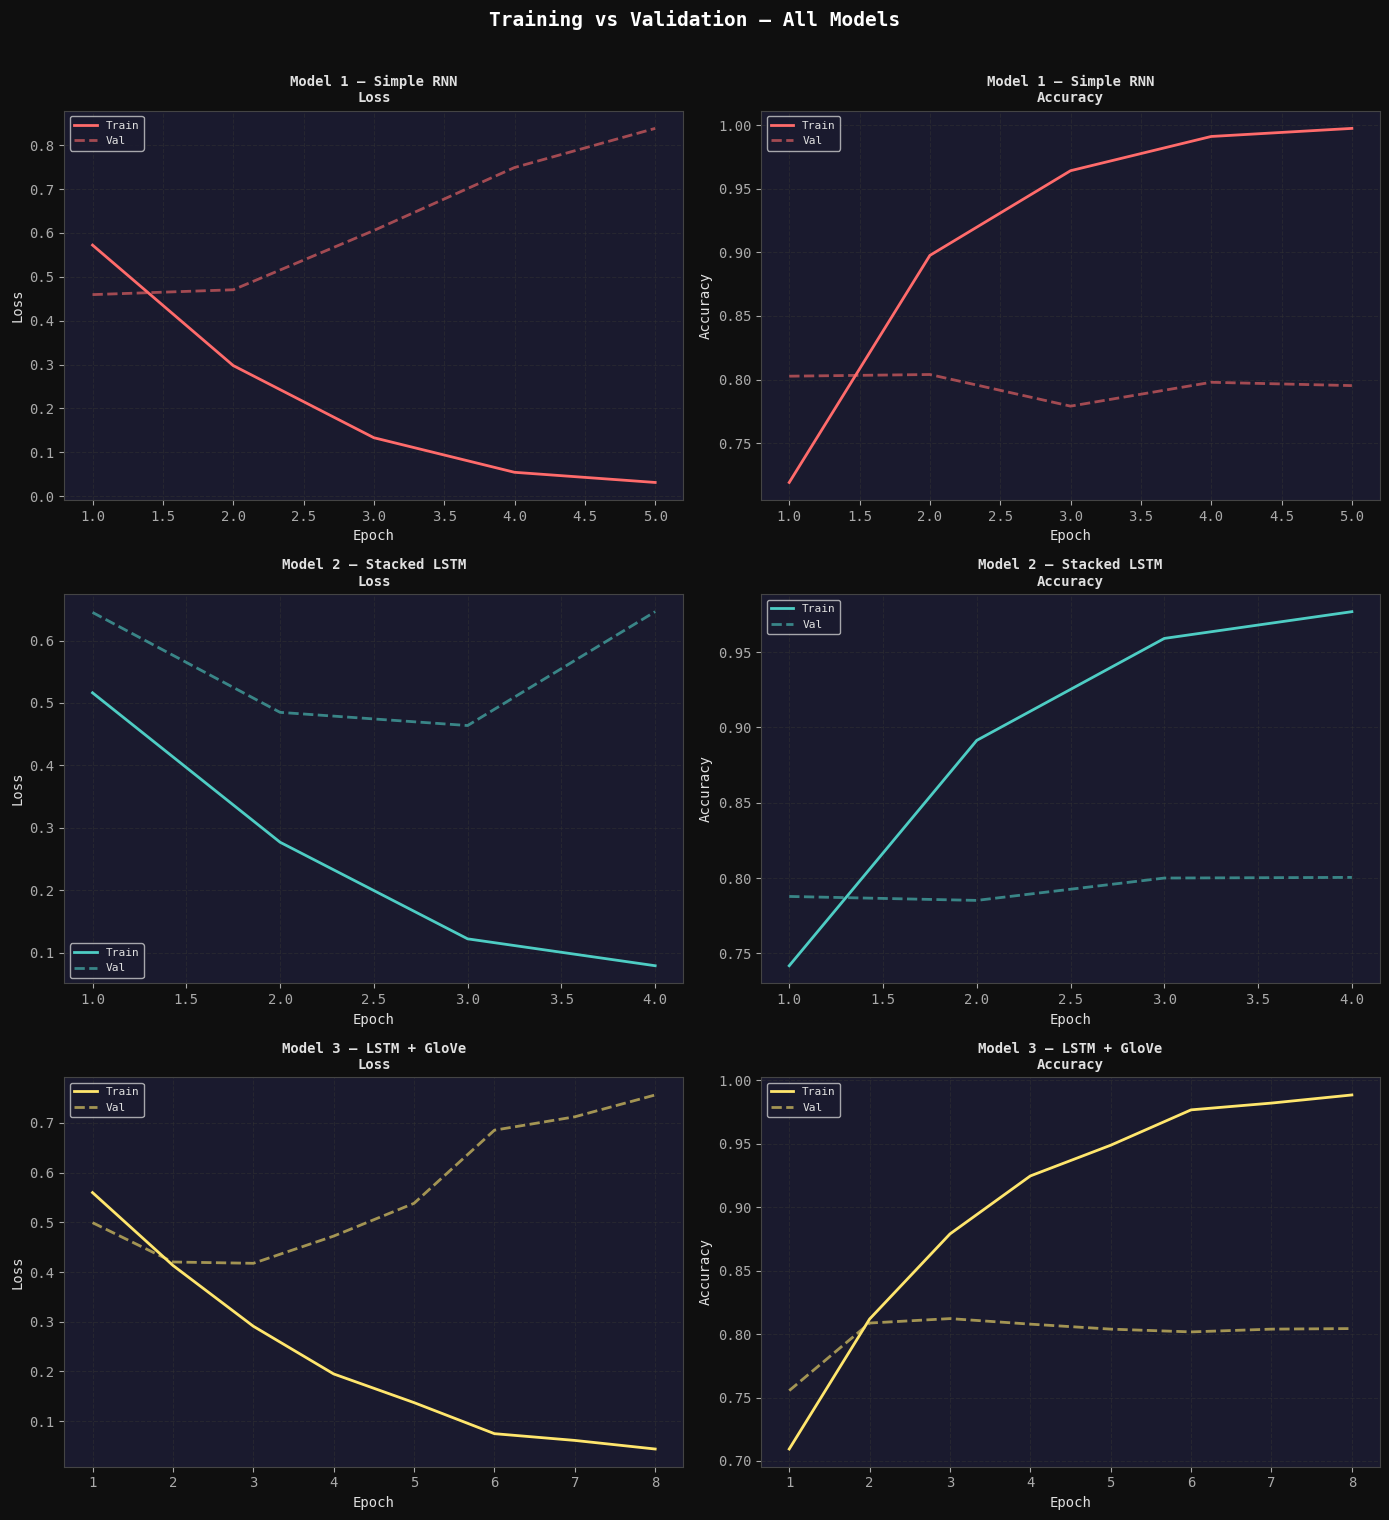

In [ ]:
def plot_history(ax_l, ax_a, hist, name, color):
    ep = range(1, len(hist.history['loss'])+1)
    ax_l.plot(ep,hist.history['loss'],    color=color,lw=2,label='Train')
    ax_l.plot(ep,hist.history['val_loss'],color=color,lw=2,linestyle='--',alpha=0.6,label='Val')
    ax_l.set_title(f'{name}\nLoss',fontweight='bold',fontsize=10)
    ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Loss')
    ax_l.legend(fontsize=8); ax_l.grid(True)

    ax_a.plot(ep,hist.history['accuracy'],    color=color,lw=2,label='Train')
    ax_a.plot(ep,hist.history['val_accuracy'],color=color,lw=2,linestyle='--',alpha=0.6,label='Val')
    ax_a.set_title(f'{name}\nAccuracy',fontweight='bold',fontsize=10)
    ax_a.set_xlabel('Epoch'); ax_a.set_ylabel('Accuracy')
    ax_a.legend(fontsize=8); ax_a.grid(True)

fig, axes = plt.subplots(3,2,figsize=(14,15))
fig.patch.set_facecolor('#0f0f0f')
plot_history(axes[0][0],axes[0][1],hist_rnn,  'Model 1 — Simple RNN',   C['m1'])
plot_history(axes[1][0],axes[1][1],hist_lstm, 'Model 2 — Stacked LSTM', C['m2'])
plot_history(axes[2][0],axes[2][1],hist_glove,'Model 3 — LSTM + GloVe', C['m3'])
fig.suptitle('Training vs Validation — All Models',
             fontsize=14,fontweight='bold',color='white',y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png',dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.show()

---
## 📈 Step 7 — Evaluation & Comparison

In [ ]:
def evaluate(model, name):
    loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    y_pred = (model.predict(X_test_pad,verbose=0).flatten() > 0.5).astype(int)
    print(f'\n{"+"*55}\n  {name}\n{"+"*55}')
    print(f'  Loss : {loss:.4f}   Accuracy : {acc*100:.2f}%')
    print(classification_report(y_test,y_pred,
          target_names=['Not Sarcastic','Sarcastic']))
    return y_pred, acc, loss

y_pred_rnn,   acc_rnn,   loss_rnn   = evaluate(model_rnn,  'Model 1 — Simple RNN')
y_pred_lstm,  acc_lstm,  loss_lstm  = evaluate(model_lstm, 'Model 2 — Stacked LSTM')
y_pred_glove, acc_glove, loss_glove = evaluate(model_glove,'Model 3 — LSTM + GloVe')


+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Model 1 — Simple RNN
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Loss : 0.4655   Accuracy : 79.14%
               precision    recall  f1-score   support

Not Sarcastic       0.79      0.82      0.80      2997
    Sarcastic       0.79      0.76      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Model 2 — Stacked LSTM
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Loss : 0.6441   Accuracy : 78.93%
               precision    recall  f1-score   support

Not Sarcastic       0.83      0.75      0.79      2997
    Sarcastic       0.75      0.84      0.79      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79

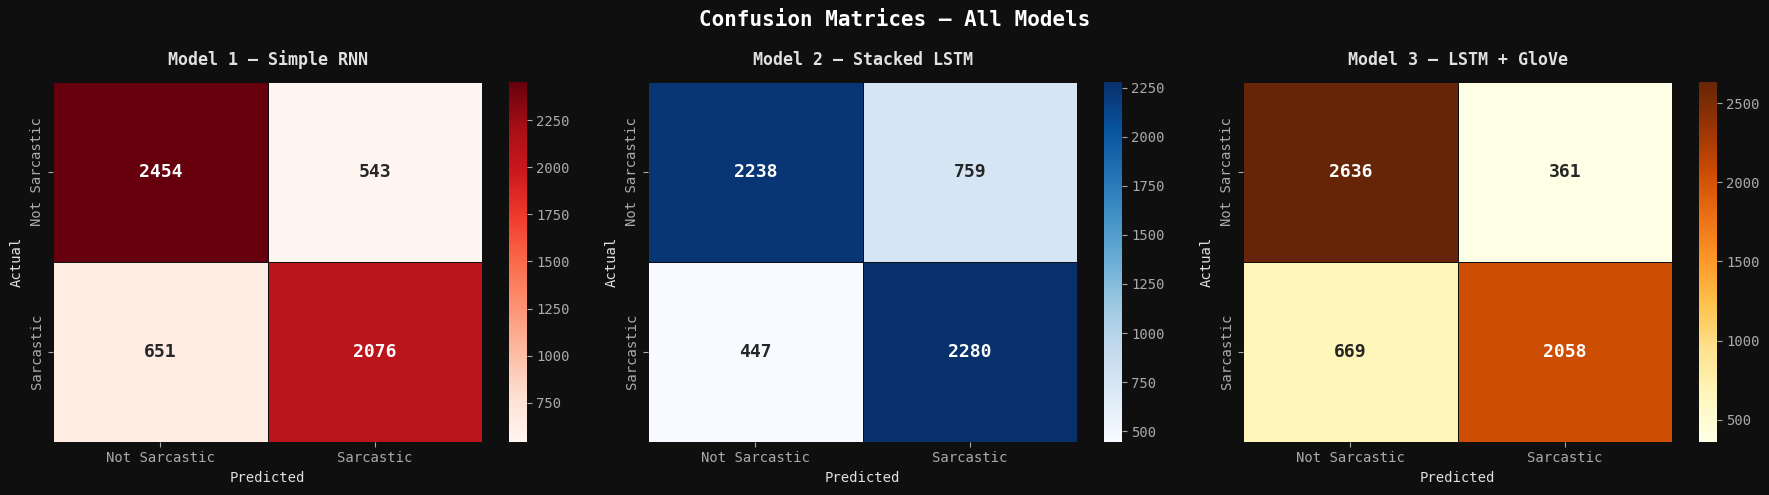

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.patch.set_facecolor('#0f0f0f')
cls = ['Not Sarcastic','Sarcastic']
for ax,(yp,name,cmap) in zip(axes,[
    (y_pred_rnn,  'Model 1 — Simple RNN',   'Reds'),
    (y_pred_lstm, 'Model 2 — Stacked LSTM', 'Blues'),
    (y_pred_glove,'Model 3 — LSTM + GloVe', 'YlOrBr')
]):
    cm = confusion_matrix(y_test,yp)
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,ax=ax,
                xticklabels=cls,yticklabels=cls,
                linewidths=0.5,linecolor='#0f0f0f',
                annot_kws={'size':13,'weight':'bold'})
    ax.set_title(name,fontweight='bold',pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('Confusion Matrices — All Models',fontsize=15,fontweight='bold',color='white')
plt.tight_layout()
plt.savefig('confusion_matrices.png',dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.show()

MODEL COMPARISON
       Model  Accuracy  Precision   Recall  F1 Score     Loss  Train Time
  Simple RNN  0.791405   0.792669 0.761276  0.776655 0.465508   10.491651
Stacked LSTM  0.789308   0.750247 0.836084  0.790843 0.644076   10.388512
LSTM + GloVe  0.820056   0.850765 0.754675  0.799845 0.423054   36.997394


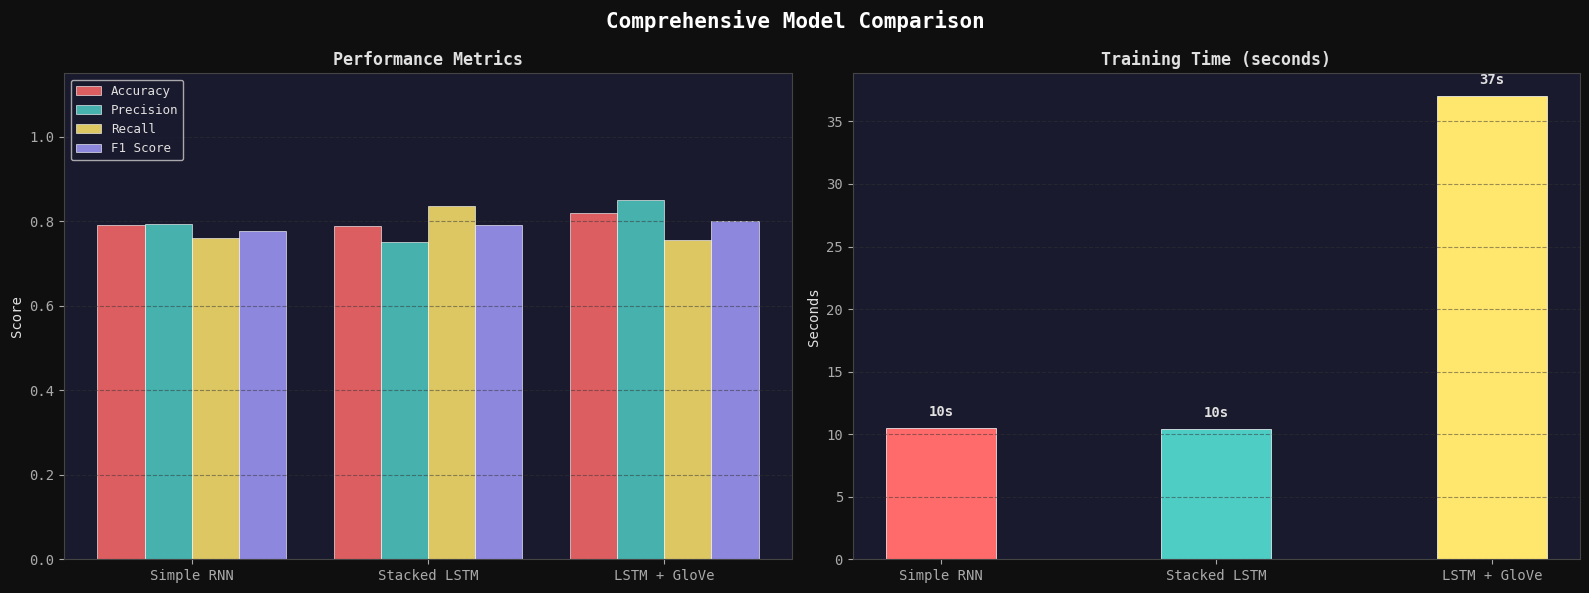

In [ ]:
# Comprehensive comparison dashboard
preds = [y_pred_rnn, y_pred_lstm, y_pred_glove]
cdf = pd.DataFrame({
    'Model'      : ['Simple RNN','Stacked LSTM','LSTM + GloVe'],
    'Accuracy'   : [acc_rnn, acc_lstm, acc_glove],
    'Precision'  : [precision_score(y_test,p) for p in preds],
    'Recall'     : [recall_score(y_test,p)    for p in preds],
    'F1 Score'   : [f1_score(y_test,p)        for p in preds],
    'Loss'       : [loss_rnn, loss_lstm, loss_glove],
    'Train Time' : [t_rnn, t_lstm, t_glove],
})
print('MODEL COMPARISON')
print(cdf.to_string(index=False))

fig, axes = plt.subplots(1,2,figsize=(16,6))
fig.patch.set_facecolor('#0f0f0f')

# Grouped metrics
x, w = np.arange(3), 0.2
for i,(col,clr) in enumerate(zip(
    ['Accuracy','Precision','Recall','F1 Score'],
    [C['m1'],C['m2'],C['m3'],'#a29bfe']
)):
    axes[0].bar(x+i*w,cdf[col],w,label=col,color=clr,alpha=0.85,
                edgecolor='white',linewidth=0.5)
axes[0].set_xticks(x+w*1.5)
axes[0].set_xticklabels(cdf['Model'],fontsize=10)
axes[0].set_ylim(0,1.15); axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics',fontweight='bold')
axes[0].legend(loc='upper left',fontsize=9); axes[0].grid(axis='y')

# Training time
bars2 = axes[1].bar(cdf['Model'],cdf['Train Time'],
                    color=[C['m1'],C['m2'],C['m3']],
                    edgecolor='white',linewidth=0.5,width=0.4)
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2,b.get_height()+1,
                 f'{b.get_height():.0f}s',ha='center',fontweight='bold')
axes[1].set_title('Training Time (seconds)',fontweight='bold')
axes[1].set_ylabel('Seconds'); axes[1].grid(axis='y')

fig.suptitle('Comprehensive Model Comparison',fontsize=15,fontweight='bold',color='white')
plt.tight_layout()
plt.savefig('model_comparison.png',dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.show()

---
## 🔍 Step 8 — Error Analysis

In [ ]:
err_df = pd.DataFrame({
    'headline' : X_test,
    'cleaned'  : [clean_text(h) for h in X_test],
    'actual'   : y_test,
    'predicted': y_pred_glove
})
err_df['correct'] = err_df['actual'] == err_df['predicted']
miss = err_df[~err_df['correct']]
fp   = miss[(miss['actual']==0)&(miss['predicted']==1)]
fn   = miss[(miss['actual']==1)&(miss['predicted']==0)]

print(f'Total samples    : {len(err_df):,}')
print(f'Misclassified    : {len(miss):,}  ({len(miss)/len(err_df)*100:.1f}%)')
print(f'False Positives  : {len(fp):,}')
print(f'False Negatives  : {len(fn):,}')

print('\n'+'='*65)
print('FALSE POSITIVES — Predicted Sarcastic, Actually Not')
print('='*65)
for _,row in fp.head(3).iterrows():
    print(f'  Headline  : {row["headline"]}')
    print(f'  Cleaned   : {row["cleaned"]}')
    print(f'  Actual: Not Sarcastic  |  Predicted: Sarcastic  ❌\n')

print('='*65)
print('FALSE NEGATIVES — Predicted Not Sarcastic, Actually Is')
print('='*65)
for _,row in fn.head(3).iterrows():
    print(f'  Headline  : {row["headline"]}')
    print(f'  Cleaned   : {row["cleaned"]}')
    print(f'  Actual: Sarcastic  |  Predicted: Not Sarcastic  ❌\n')

Total samples    : 5,724
Misclassified    : 1,030  (18.0%)
False Positives  : 361
False Negatives  : 669

FALSE POSITIVES — Predicted Sarcastic, Actually Not
  Headline  : rex tillerson call report ouster laughable
  Cleaned   : rex tillerson call report ouster laughable
  Actual: Not Sarcastic  |  Predicted: Sarcastic  ❌

  Headline  : huckabee back denying abortion yearold raped stepfather
  Cleaned   : huckabee back denying abortion yearold raped stepfather
  Actual: Not Sarcastic  |  Predicted: Sarcastic  ❌

  Headline  : joe arpaios concentration camp finally closed
  Cleaned   : joe arpaios concentration camp finally closed
  Actual: Not Sarcastic  |  Predicted: Sarcastic  ❌

FALSE NEGATIVES — Predicted Not Sarcastic, Actually Is
  Headline  : group christie campaign deserter found forest
  Cleaned   : group christie campaign deserter found forest
  Actual: Sarcastic  |  Predicted: Not Sarcastic  ❌

  Headline  : democratic congressman protest trump environmental policy bringing 

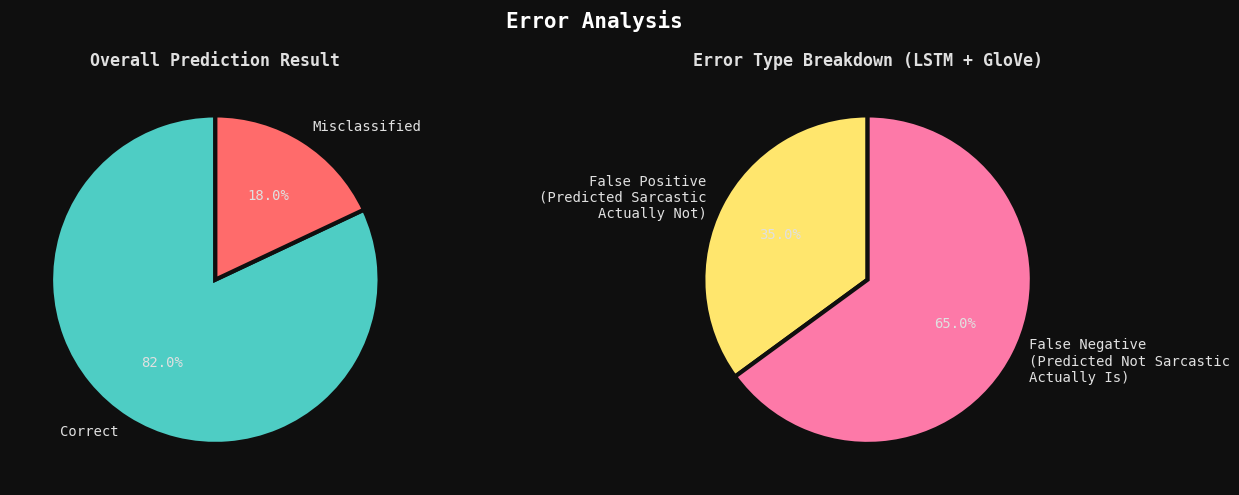


ERROR ANALYSIS DISCUSSION
1. Vocabulary Overlap (False Positives):
   Words like 'scientist','discover','report' appear in both sarcastic
   and genuine headlines. The model associates them with sarcasm.

2. Subtle / Deadpan Sarcasm (False Negatives):
   Headlines that look factual but are satirical require world knowledge
   the model cannot capture from word patterns alone.

3. Short Headlines:
   Very short cleaned text provides too little context for classification.

Suggested Improvements:
   - Use BERT/transformer for deep contextual understanding.
   - Fine-tune GloVe embeddings (trainable=True).
   - Include article body text alongside the headline.



In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.patch.set_facecolor('#0f0f0f')

axes[0].pie(
    [len(err_df)-len(miss), len(miss)],
    labels=['Correct','Misclassified'],
    colors=[C['n'],C['s']],autopct='%1.1f%%',startangle=90,
    wedgeprops={'edgecolor':'#0f0f0f','linewidth':3}
)
axes[0].set_title('Overall Prediction Result',fontweight='bold')

axes[1].pie(
    [len(fp),len(fn)],
    labels=['False Positive\n(Predicted Sarcastic\nActually Not)',
            'False Negative\n(Predicted Not Sarcastic\nActually Is)'],
    colors=['#ffe66d','#fd79a8'],autopct='%1.1f%%',startangle=90,
    wedgeprops={'edgecolor':'#0f0f0f','linewidth':3}
)
axes[1].set_title('Error Type Breakdown (LSTM + GloVe)',fontweight='bold')

fig.suptitle('Error Analysis',fontsize=15,fontweight='bold',color='white')
plt.tight_layout()
plt.savefig('error_analysis.png',dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.show()

print("""
ERROR ANALYSIS DISCUSSION
==========================
1. Vocabulary Overlap (False Positives):
   Words like 'scientist','discover','report' appear in both sarcastic
   and genuine headlines. The model associates them with sarcasm.

2. Subtle / Deadpan Sarcasm (False Negatives):
   Headlines that look factual but are satirical require world knowledge
   the model cannot capture from word patterns alone.

3. Short Headlines:
   Very short cleaned text provides too little context for classification.

Suggested Improvements:
   - Use BERT/transformer for deep contextual understanding.
   - Fine-tune GloVe embeddings (trainable=True).
   - Include article body text alongside the headline.
""")

---
## 🖥️ Step 9 — GUI: Real-Time Sarcasm Detector (Gradio)

In [ ]:
import gradio as gr

MODEL_MAP = {
    'LSTM + GloVe (Best)' : model_glove,
    'Stacked LSTM'        : model_lstm,
    'Simple RNN'          : model_rnn,
}

def predict_sarcasm(headline, model_choice):
    if not headline.strip():
        return '⚠️ Enter a headline.', '', '', ''
    model   = MODEL_MAP[model_choice]
    cleaned = clean_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq,maxlen=MAX_LEN,padding='post',truncating='post')
    prob    = float(model.predict(padded,verbose=0)[0][0])
    label   = 'Sarcastic 😏' if prob > 0.5 else 'Not Sarcastic 📰'
    conf    = max(prob,1-prob)*100
    bar     = '█'*int(conf/5) + '░'*(20-int(conf/5))
    detail  = (
        f'Sarcasm prob     : {prob*100:.1f}%\n'
        f'Not-sarcasm prob : {(1-prob)*100:.1f}%\n'
        f'Model            : {model_choice}'
    )
    return label, f'{conf:.1f}%  [{bar}]', cleaned or '(empty after cleaning)', detail

css = """
body, .gradio-container {
    background: linear-gradient(135deg,#0f0f0f 0%,#1a1a2e 50%,#16213e 100%) !important;
    font-family: 'Courier New', monospace !important;
}
.gr-button-primary {
    background: linear-gradient(90deg,#ff6b6b,#ffe66d) !important;
    color: #0f0f0f !important; font-weight: bold !important;
    border: none !important; border-radius: 8px !important; font-size: 16px !important;
}
.gr-button-primary:hover { opacity:0.85 !important; transform:scale(1.02) !important; }
label { color:#4ecdc4 !important; font-weight:bold !important; }
.gr-input, .gr-box, textarea, input, select {
    background:#1a1a2e !important; color:#e0e0e0 !important;
    border:1px solid #444 !important; border-radius:8px !important;
}
"""

with gr.Blocks(css=css, title='Sarcasm Detector — 6CS012') as demo:

    gr.HTML("""
    <div style='text-align:center;padding:20px 0;'>
      <h1 style='color:#ff6b6b;font-size:2.2em;font-family:monospace;
                 text-shadow:0 0 20px #ff6b6b88;'>🎭 Sarcasm Detector</h1>
      <p style='color:#4ecdc4;font-size:1.05em;font-family:monospace;'>
        6CS012 · Herald College Kathmandu · University of Wolverhampton
      </p>
      <p style='color:#888;font-size:0.9em;'>
        Enter a news headline · choose a model · detect sarcasm in real-time
      </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=3):
            inp_headline = gr.Textbox(
                label='📝 News Headline',
                placeholder='e.g.  area man becomes expert after reading one article',
                lines=3
            )
            inp_model = gr.Dropdown(
                label='🤖 Choose Model',
                choices=list(MODEL_MAP.keys()),
                value='LSTM + GloVe (Best)'
            )
            btn = gr.Button('🔍  Analyse Headline', variant='primary')

        with gr.Column(scale=2):
            out_label  = gr.Textbox(label='🎯 Prediction')
            out_conf   = gr.Textbox(label='📊 Confidence')
            out_clean  = gr.Textbox(label='🧹 Cleaned Text')
            out_detail = gr.Textbox(label='📋 Details', lines=4)

    gr.HTML('<hr style="border-color:#333;margin:16px 0;">')
    gr.HTML('<p style="color:#4ecdc4;font-family:monospace;font-weight:bold;">⚡ Example Headlines:</p>')

    gr.Examples(
        examples=[
            ['area man becomes expert after reading one article',              'LSTM + GloVe (Best)'],
            ['scientists confirm sun rises every day for billionth time',      'LSTM + GloVe (Best)'],
            ['government solves poverty by renaming it something else',        'LSTM + GloVe (Best)'],
            ['local coffee shop raises prices to keep things affordable',      'LSTM + GloVe (Best)'],
            ['new study finds that exercise is good for health',               'LSTM + GloVe (Best)'],
            ['scientists discover new species of fish in amazon river',        'LSTM + GloVe (Best)'],
            ['president signs new climate change bill into law',               'LSTM + GloVe (Best)'],
            ['man who founded company to help people now helps company',       'Stacked LSTM'],
            ['new app helps users spend less time on phone using their phone', 'Simple RNN'],
        ],
        inputs=[inp_headline, inp_model]
    )

    btn.click(
        fn=predict_sarcasm,
        inputs=[inp_headline, inp_model],
        outputs=[out_label, out_conf, out_clean, out_detail]
    )

    gr.HTML("""
    <div style='text-align:center;padding:16px 0;color:#555;
                font-family:monospace;font-size:0.85em;'>
      6CS012 Final Portfolio · Herald College Kathmandu · University of Wolverhampton
    </div>
    """)

demo.launch(share=True)
print('Gradio app running — open the public link above.')

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8df40be44aa56f43ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio app running — open the public link above.


---
## ✅ Summary

| Component | Details |
|---|---|
| **Dataset** | Sarcastic Headlines — 28,619 records, binary classification |
| **Preprocessing** | Lowercase · Contraction expansion · URL/mention/digit removal · Stopwords · Lemmatization |
| **Split** | 80% Train / 20% Test — stratified |
| **Class Weights** | `compute_class_weight('balanced')` applied to all models |
| **Model 1** | Simple RNN + Trainable Embedding (128d) + L2 regularization |
| **Model 2** | Stacked LSTM (128→64) + BatchNorm + Trainable Embedding (128d) |
| **Model 3** | Stacked LSTM (128→64) + BatchNorm + Frozen GloVe Embedding (50d) |
| **Callbacks** | EarlyStopping (patience=3) + ReduceLROnPlateau (patience=2) |
| **Evaluation** | Accuracy · Precision · Recall · F1 · Confusion Matrix · Training Time |
| **GUI** | Gradio — 3-model selector · confidence bar · cleaned text · detail panel |
